In [1]:
library(Seurat)
library(patchwork)
library(tidyverse) 
library(SingleR)
library(celldex)
library(SingleCellExperiment)
library(dplyr)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


In [2]:
data_int <- "../../results/sc_rna/03_annot/intermediate"

# Define directories
dir_fig <- "../../results/sc_rna/05_TIM_subclustering/figures"
dir_int <- "../../results/sc_rna/05_TIM_subclustering/intermediate"

# Make sure directories exist
dir.create(dir_fig, recursive = TRUE, showWarnings = FALSE)
dir.create(dir_int, recursive = TRUE, showWarnings = FALSE)

In [3]:
merged_filt <- readRDS(file.path(data_int, "merged_filt.rds"))

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


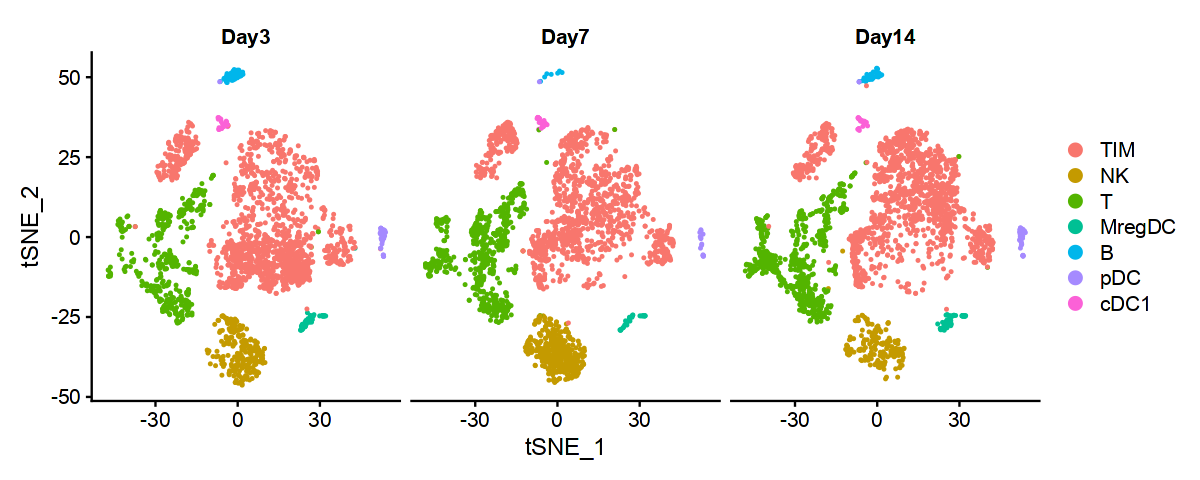

In [4]:
options(repr.plot.width = 10, repr.plot.height = 4)
DimPlot(merged_filt, reduction = "tsne", split.by='day')

In [5]:
TIM <- subset(merged_filt, idents = c("TIM"))

# Subclustering

In [6]:
TIM <- NormalizeData(TIM)
TIM <- FindVariableFeatures(TIM, selection.method = "vst", nfeatures = 2000)
TIM <- ScaleData(TIM, features = rownames(TIM))
TIM <- RunPCA(TIM)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  Clec4d, Fth1, Cxcl2, Cd9, Ankrd33b, Hilpda, Ier3, Hcar2, Ccl3, Ftl1 
	   S100a8, S100a9, Grina, Egr1, Basp1, Egln3, Tnfrsf23, Tmem189, Ero1l, Mirt1 
	   Smox, Slc7a11, Fnip2, 1700017B05Rik, Cd24a, E230032D23Rik, Cxcl3, Plin2, Gadd45a, Clec4e 
Negative:  Ifi30, Cst3, H2-DMa, Pnp, Syngr2, H2afz, Naaa, Hspa8, H2-DMb1, Napsa 
	   Ptma, Plac8, Ms4a4c, Samhd1, Ctsc, Rps2, Pycard, Rpl12, Ly86, Cd74 
	   Rps27l, Ranbp1, Lyz2, Prdx1, Gng10, Nfkb1, Irf8, Zyx, Slamf8, Ybx3 
PC_ 2 
Positive:  Dab2, Lgmn, C3ar1, Gapdh, Lgals1, Arg1, Tpi1, Pgk1, Mif, Sdc4 
	   Snx5, Ccl7, Ctsl, Fcgr2b, Aldoa, Tubb5, Lgals3, Mt1, Emp1, Gpi1 
	   Ccl2, Ctsb, Ccl9, Msr1, Sdc3, Slc7a8, Stab1, Pf4, Cstb, Bsg 
Negative:  Gsr, Lsp1, Csf3r, Ifitm6, S100a9, Hp, Itgal, S100a8, Hdc, Sell 
	   Samhd1, G0s2, Mgst1, Pglyrp1, Mirt1, Zyx, Irf1, Il1r2, Tnfaip2, Lmnb1 
	   Ypel3, Retnlg, Cxcr2, Itga4, Mmp9, Tspa

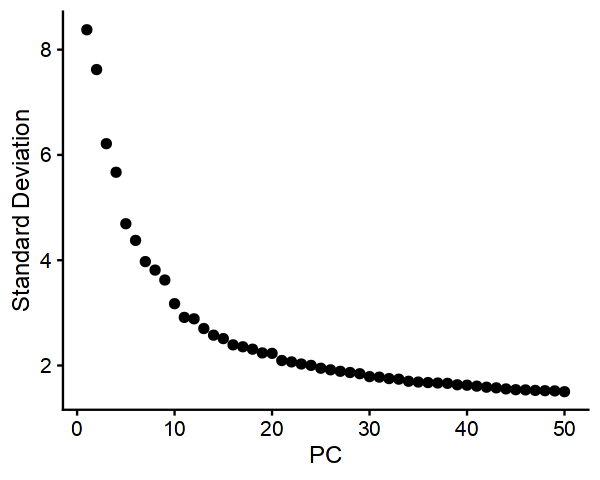

In [7]:
options(repr.plot.width = 5, repr.plot.height = 4)
ElbowPlot(TIM, ndims = 50)

In [8]:
TIM <- FindNeighbors(TIM, dims = 1:30)

resolutions <- c(0.1, 0.2, 0.3, 0.4, 0.5, 0.6)
for (res in resolutions) {
  col_name <- paste0("TIM_snn_res.", res)
  TIM <- FindClusters(
    TIM,
    resolution = res,
    cluster.name = col_name
  )
}

TIM <- RunUMAP(TIM, dims = 1:30)
TIM <- RunTSNE(TIM, dims = 1:30)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4582
Number of edges: 163282

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9388
Number of communities: 5
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4582
Number of edges: 163282

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9082
Number of communities: 6
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4582
Number of edges: 163282

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8863
Number of communities: 7
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4582
Number of edges: 163282

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8692
Number of communities: 8
Elapsed time: 0 seconds
Modularity Optimizer

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
06:23:33 UMAP embedding parameters a = 0.9922 b = 1.112

06:23:33 Read 4582 rows and found 30 numeric columns

06:23:33 Using Annoy for neighbor search, n_neighbors = 30

06:23:33 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

06:23:33 Writing NN index file to temp file /tmp/RtmpCg404v/file2cbda13fac7df

06:23:33 Searching Annoy index using 1 thread, search_k = 3000

06:23:35 Annoy recall = 100%

06:23:36 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors 

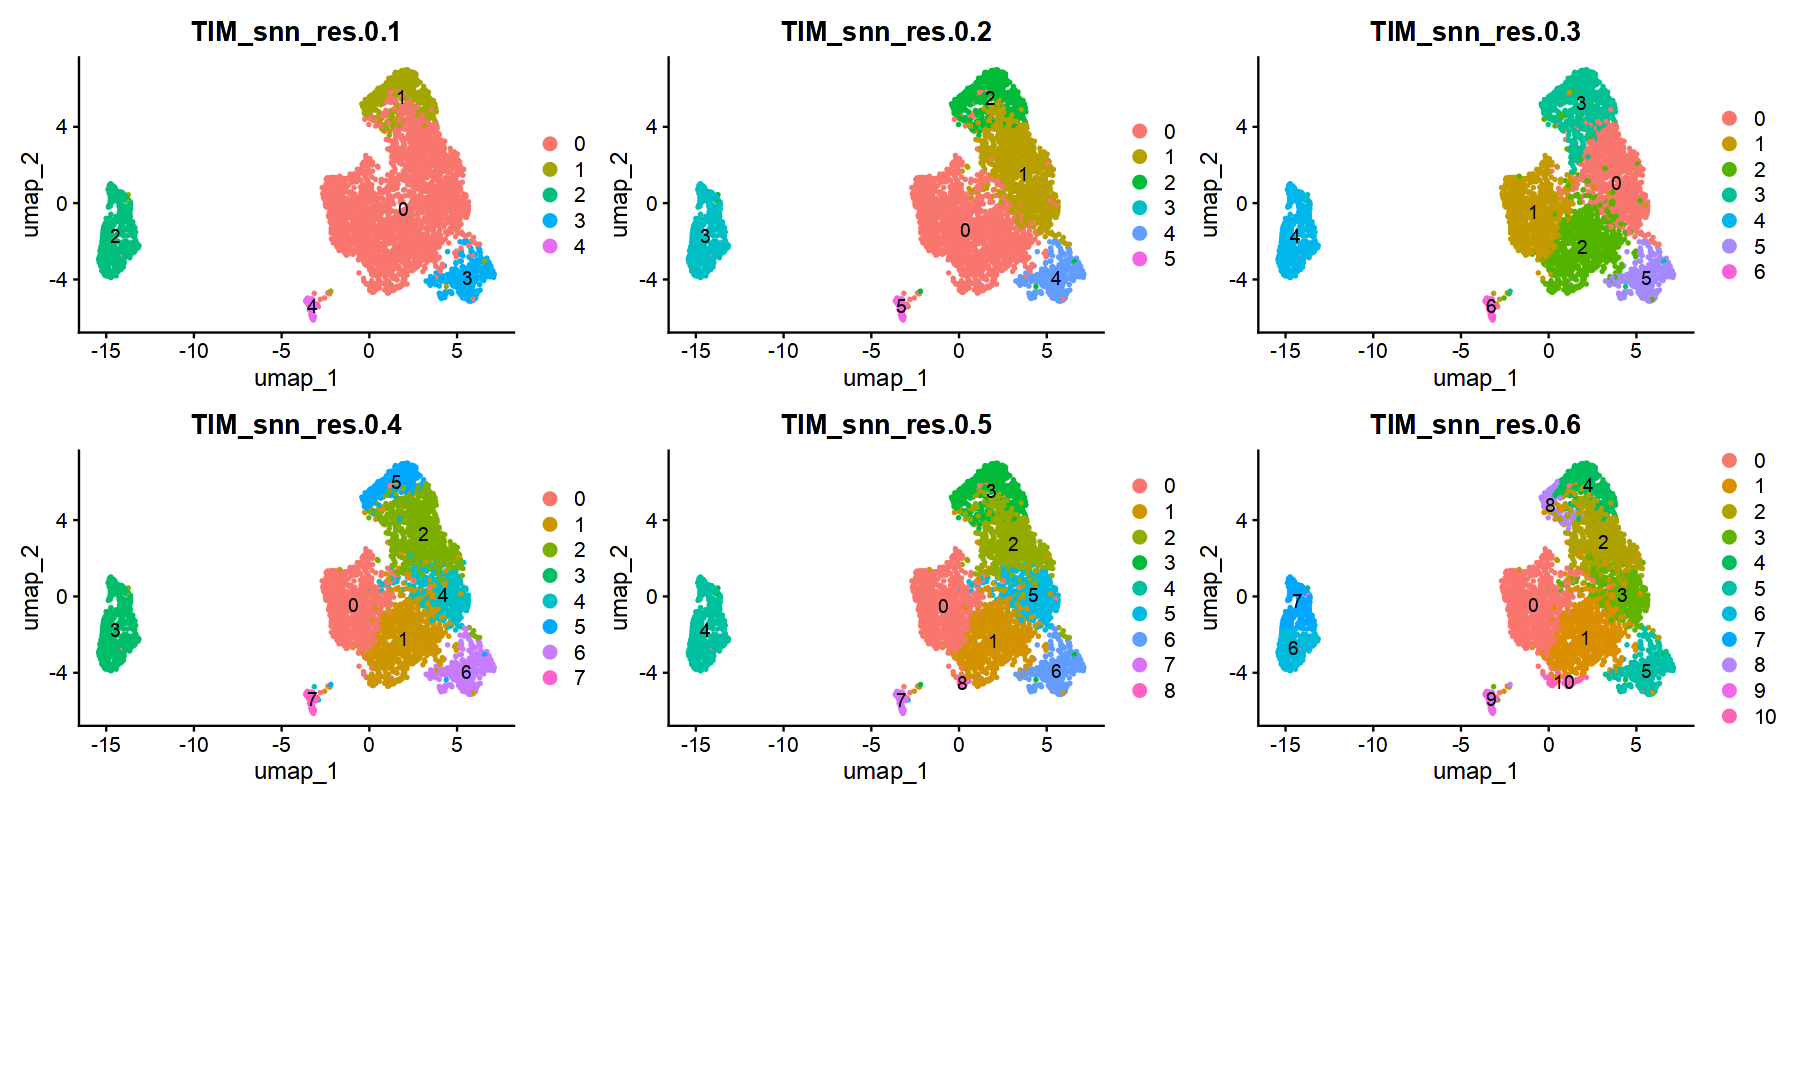

In [9]:
r01 <- DimPlot(TIM, reduction = "umap", group.by = "TIM_snn_res.0.1", label = TRUE)
r02 <- DimPlot(TIM, reduction = "umap", group.by = "TIM_snn_res.0.2", label = TRUE)
r03 <- DimPlot(TIM, reduction = "umap", group.by = "TIM_snn_res.0.3", label = TRUE)
r04 <- DimPlot(TIM, reduction = "umap", group.by = "TIM_snn_res.0.4", label = TRUE)
r05 <- DimPlot(TIM, reduction = "umap", group.by = "TIM_snn_res.0.5", label = TRUE)
r06 <- DimPlot(TIM, reduction = "umap", group.by = "TIM_snn_res.0.6", label = TRUE)

options(repr.plot.width = 15, repr.plot.height = 9)
(r01 + r02 + r03 + r04 + r05 + r06) +
  plot_layout(ncol = 3, nrow = 3)

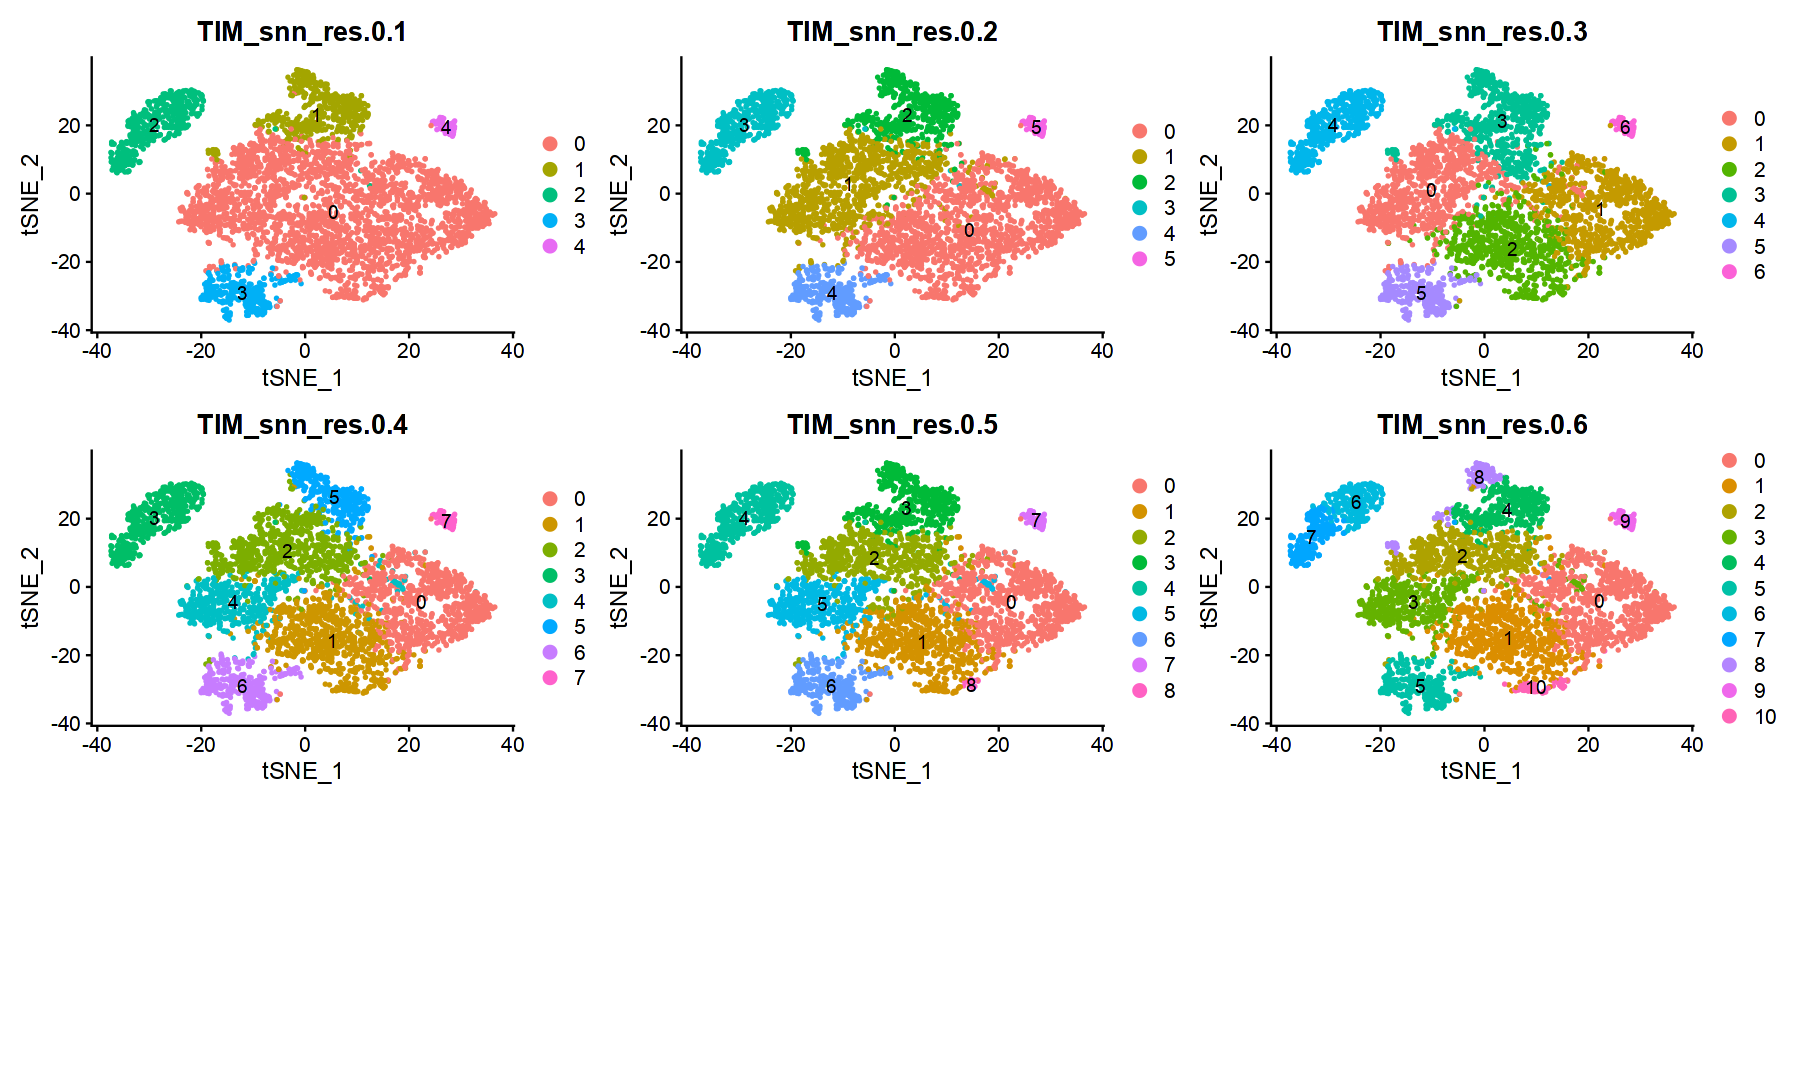

In [150]:
r01 <- DimPlot(TIM, reduction = "tsne", group.by = "TIM_snn_res.0.1", label = TRUE)
r02 <- DimPlot(TIM, reduction = "tsne", group.by = "TIM_snn_res.0.2", label = TRUE)
r03 <- DimPlot(TIM, reduction = "tsne", group.by = "TIM_snn_res.0.3", label = TRUE)
r04 <- DimPlot(TIM, reduction = "tsne", group.by = "TIM_snn_res.0.4", label = TRUE)
r05 <- DimPlot(TIM, reduction = "tsne", group.by = "TIM_snn_res.0.5", label = TRUE)
r06 <- DimPlot(TIM, reduction = "tsne", group.by = "TIM_snn_res.0.6", label = TRUE)

options(repr.plot.width = 15, repr.plot.height = 9)
(r01 + r02 + r03 + r04 + r05 + r06) +
  plot_layout(ncol = 3, nrow = 3)

In [10]:
#Idents(TIM) <- "TIM_snn_res.0.3"
Idents(TIM) <- "TIM_snn_res.0.2"

In [11]:
saveRDS(TIM, file = file.path(dir_int, "TIM1.rds"))

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’



In [12]:
TIM <- readRDS(file.path(dir_int, "TIM1.rds"))

In [13]:
head(TIM)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,day,RNA_snn_res.0.3,seurat_clusters,refilt_res.0.5,SingleR_main,celltype_fine,celltype_broad,TIM_snn_res.0.1,TIM_snn_res.0.2,TIM_snn_res.0.3,TIM_snn_res.0.4,TIM_snn_res.0.5,TIM_snn_res.0.6
,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<chr>,<chr>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
Day3_AAACCCACAGAAGCGT-1,day03,6319,1899,2.310492,Day3,1,0,3,Macrophages,MonoMac,TIM,0,0,1,0,0,0
Day3_AAACCCATCAACGTGT-1,day03,1426,544,9.186536,Day3,7,6,6,Neutrophils,Neutrophil,TIM,2,3,4,3,4,6
Day3_AAACCCATCTGCTCTG-1,day03,15119,3407,2.215755,Day3,0,3,5,Macrophages,MonoMac,TIM,0,1,0,4,5,3
Day3_AAACGCTAGCGCCCAT-1,day03,6463,1616,2.661303,Day3,1,0,3,Macrophages,MonoMac,TIM,0,0,1,0,0,0
Day3_AAAGAACCAATAGAGT-1,day03,9158,2759,1.976414,Day3,1,10,0,Macrophages,MonoMac,TIM,0,0,2,1,1,10
Day3_AAAGAACCACAAGTGG-1,day03,8090,2325,1.161928,Day3,0,2,1,Monocytes,MonoMac,TIM,0,1,0,2,2,2
Day3_AAAGAACGTCGTGCCA-1,day03,3137,1365,1.785145,Day3,0,3,5,Monocytes,MonoMac,TIM,0,1,0,4,5,3
Day3_AAAGGATAGAGTTGCG-1,day03,9583,2499,2.671397,Day3,0,2,1,Monocytes,MonoMac,TIM,0,1,0,2,2,2
Day3_AAAGGATGTCTTGCGG-1,day03,18933,3792,3.137379,Day3,1,1,0,Macrophages,MonoMac,TIM,0,0,2,1,1,1


# Annotation

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


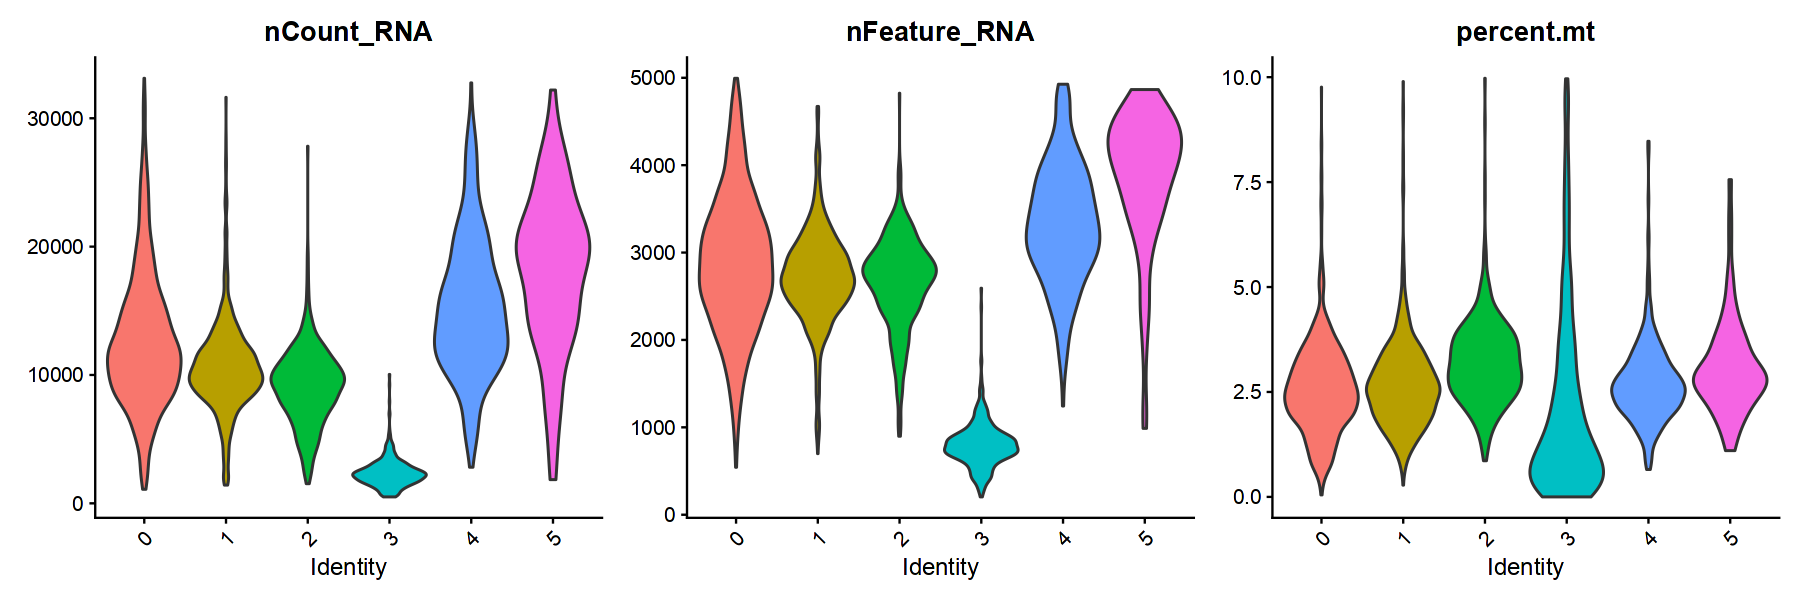

In [14]:
options(repr.plot.width = 15, repr.plot.height = 5)
p1 <- VlnPlot(
  TIM,
  features = c("nCount_RNA", "nFeature_RNA", "percent.mt"),
  pt.size = 0
) + NoLegend()

p1

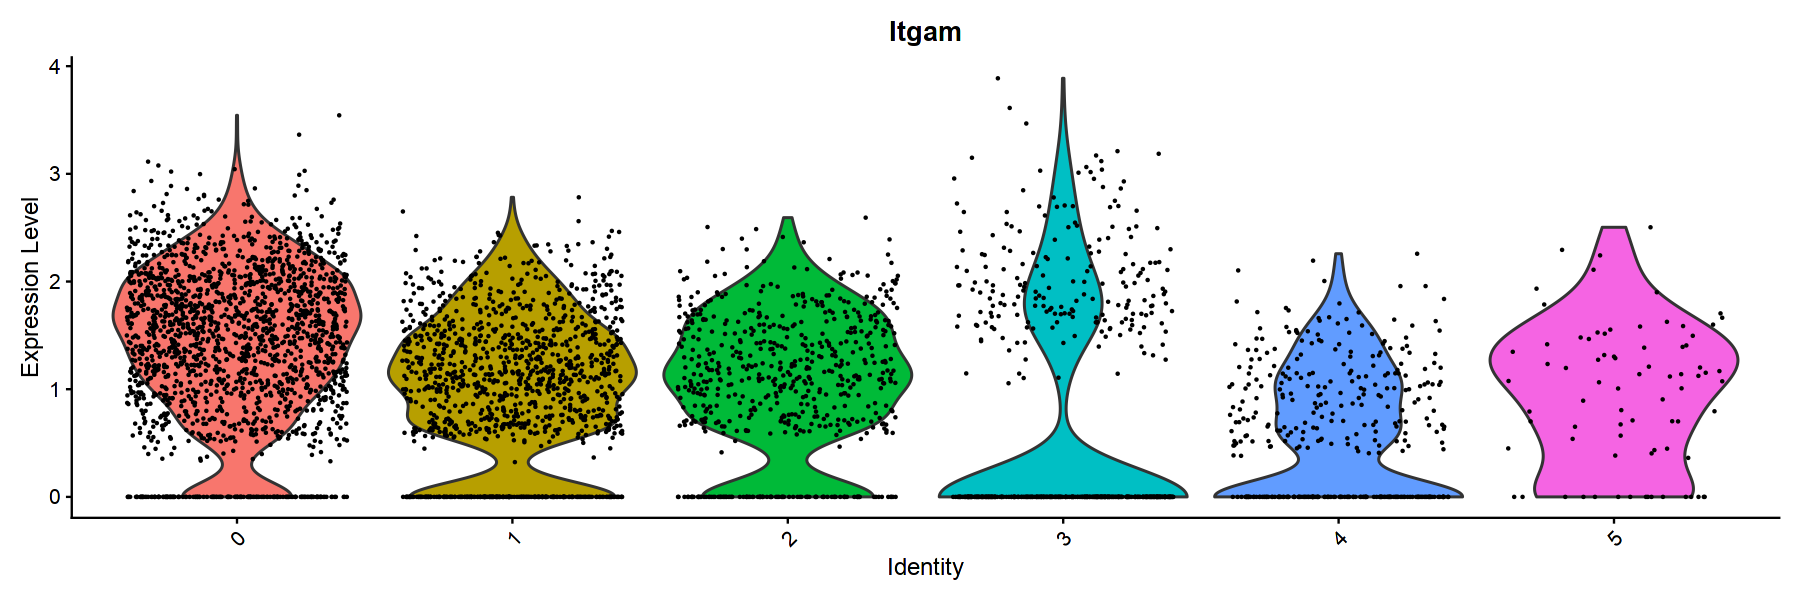

In [15]:
options(repr.plot.width = 15, repr.plot.height = 5)
p1 <- VlnPlot(
  TIM,
  features = c("Itgam"),
  pt.size = 0.01
) + NoLegend()

p1

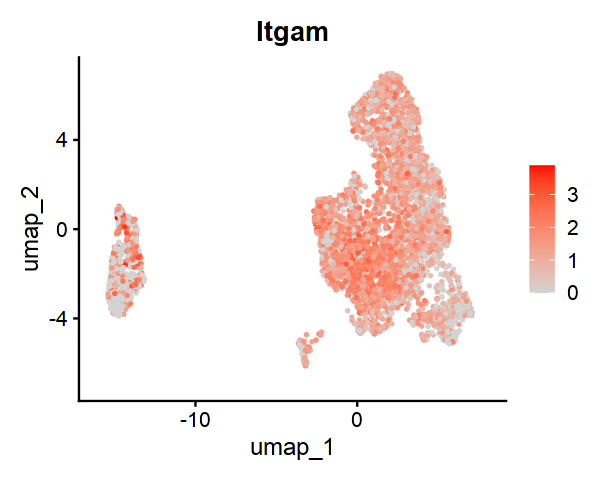

In [16]:
options(repr.plot.width = 5, repr.plot.height = 4)
FeaturePlot(TIM, features = c("Itgam"), ncol=1, cols = c("lightgrey", "red"))

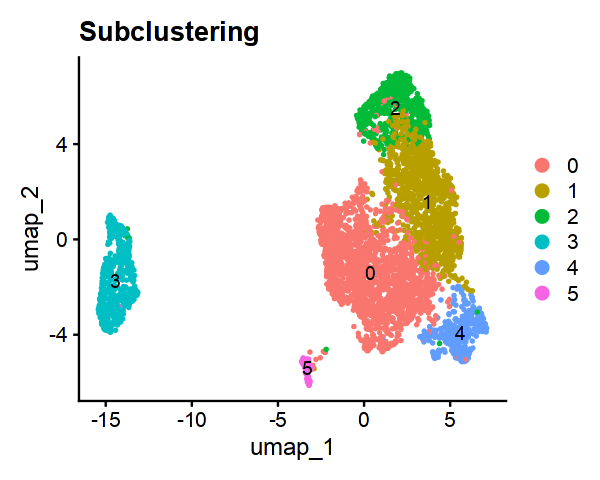

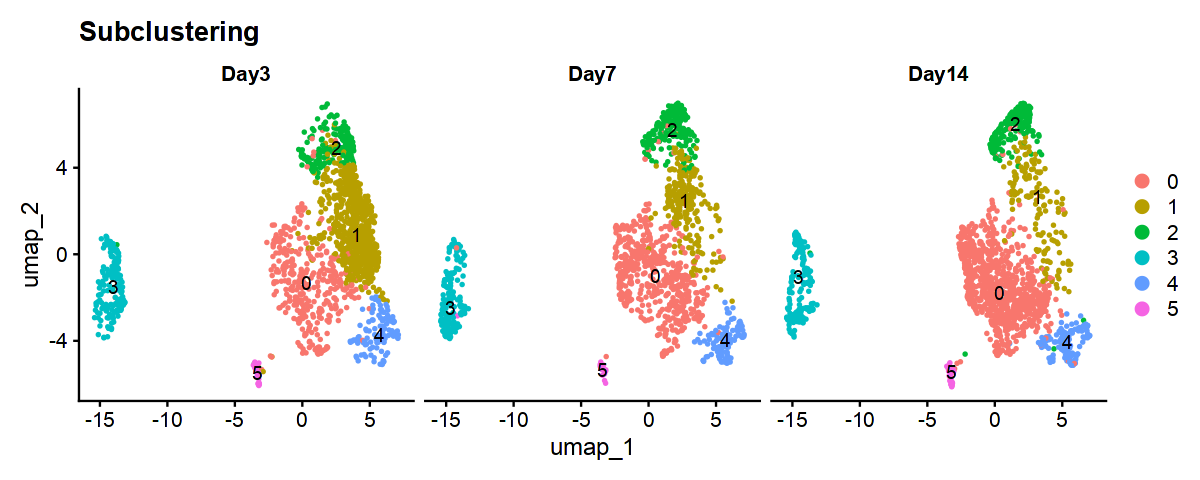

In [17]:
options(repr.plot.width = 5, repr.plot.height = 4)
p1 <- DimPlot(TIM, label = TRUE) + 
 ggtitle("Subclustering") 

p1

options(repr.plot.width = 10, repr.plot.height = 4)
p1 <- DimPlot(TIM, label = TRUE, split.by='day') + 
 ggtitle("Subclustering") 

p1

# SingleR

In [18]:
ref <- celldex::ImmGenData()  # Mouse

expr_mat <- GetAssayData(TIM, assay = "RNA", layer = "data")

labels = ref$label.main

# SingleR
sr_main <- SingleR(
    test = expr_mat,
    ref = ref,
    labels= ref$label.main
)

TIM$SingleR_main <- sr_main$labels

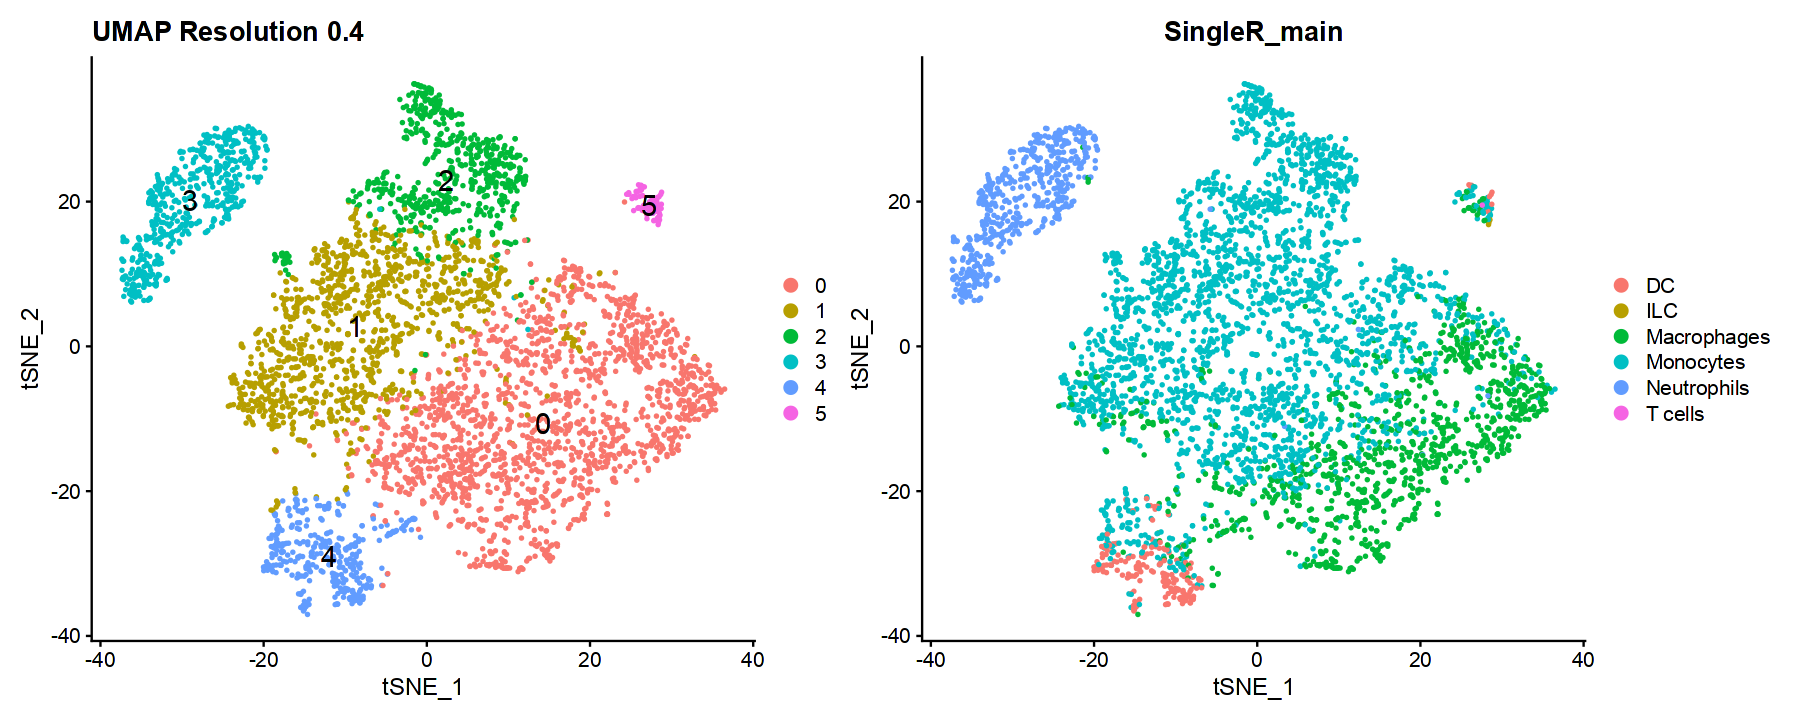

In [19]:
options(repr.plot.width = 15, repr.plot.height = 6)
p1 <- DimPlot(TIM, label.size = 6,reduction = "tsne",  label=TRUE)+ ggtitle("UMAP Resolution 0.4")
p3 <- DimPlot(TIM, group.by = 'SingleR_main', reduction = "tsne", label = FALSE, label.size = 6)+ ggtitle("SingleR_main")

p1+p3

In [21]:
saveRDS(TIM, file = file.path(dir_int, "TIM2_SingleR.rds"))

# Annotation

In [180]:
TIM <- readRDS(file.path(dir_int, "TIM2_SingleR.rds"))

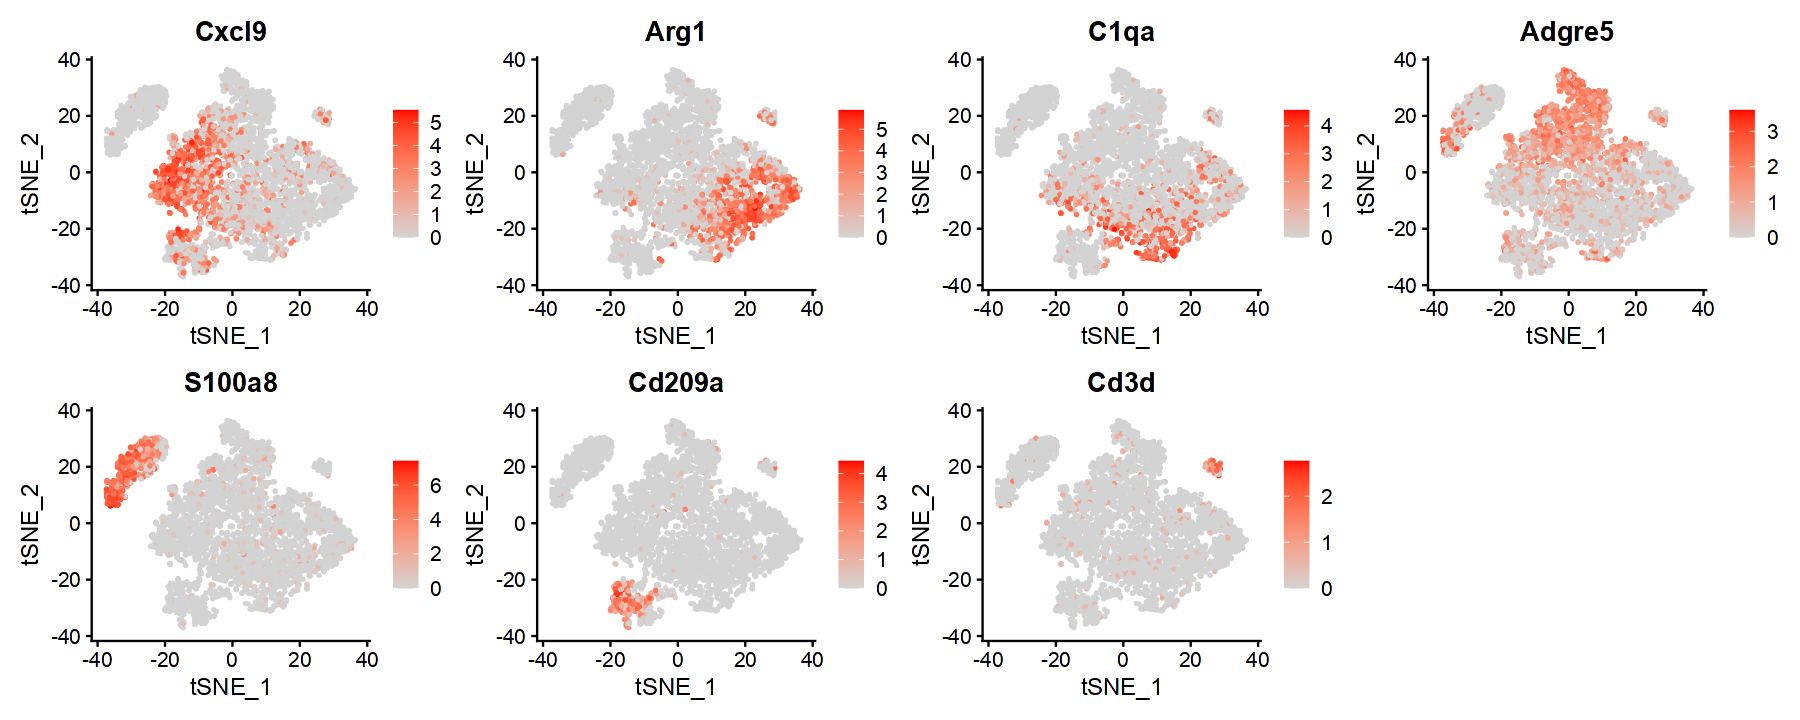

In [181]:
options(repr.plot.width = 15, repr.plot.height = 6)
FeaturePlot(TIM, 
            reduction ='tsne',
            features = c("Cxcl9",  # IFNγ-response
                         "Arg1",   # Regulatory
                         "C1qa",   # Complement
                         "Adgre5", # Monocyte
                         "S100a8", # Neutrophil
                         "Cd209a", # cDC2
                         "Cd3d"  　# Tcell
                        ), ncol=4, cols = c("lightgrey", "red"))

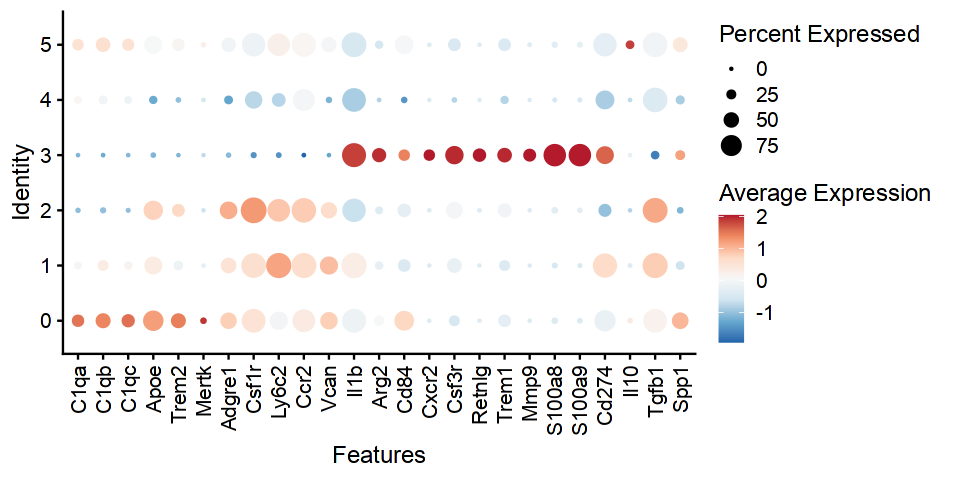

In [186]:
# 4) DotPlot lineage marker 

lineage_list <- c(
  "C1qa", "C1qb", "C1qc", "Apoe", "Trem2", "Mertk", "Adgre1", "Csf1r",
 "Ly6c2", "Ccr2", "Vcan", "Il1b", "Arg2", "Cd84",
 "Cxcr2", "Csf3r", "Retnlg", "Trem1", "Mmp9", 
  "S100a8", "S100a9", "Cd274", "Il10", "Tgfb1", "Spp1"
)

options(repr.plot.width = 8, repr.plot.height = 4)

DotPlot(TIM, features = lineage_list, cols = "RdBu") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))

In [240]:
TIM_type <- c(
  "0" = "#0 TAM",
  "1" = "#1 IFN-Mo",
  "2" = "#2 Cx3cr1+ Mo",
  "3" = "#3 TAN",
  "4" = "#4 cDC2",
  "5" = "#5 T cell"
)

desired_levels <- c(
  "#0 TAM",
  "#1 IFN-Mo",
  "#2 Cx3cr1+ Mo",
  "#3 TAN",
  "#4 cDC2",
  "#5 T cell"
)

TIM$TIM_type <- unname(TIM_type[as.character(Idents(TIM))])

TIM$TIM_type <- factor(
  TIM$TIM_type,
  levels = desired_levels
)

In [241]:
levels(TIM)

[1] "0" "1" "2" "3" "4" "5"

In [242]:
head(TIM)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,day,RNA_snn_res.0.3,seurat_clusters,refilt_res.0.5,SingleR_main,celltype_fine,celltype_broad,TIM_snn_res.0.1,TIM_snn_res.0.2,TIM_snn_res.0.3,TIM_snn_res.0.4,TIM_snn_res.0.5,TIM_snn_res.0.6,TIM_type
,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>,<chr>,<chr>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
Day3_AAACCCACAGAAGCGT-1,day03,6319,1899,2.310492,Day3,1,0,3,Macrophages,MonoMac,TIM,0,0,1,0,0,0,#0 TAM
Day3_AAACCCATCAACGTGT-1,day03,1426,544,9.186536,Day3,7,6,6,Neutrophils,Neutrophil,TIM,2,3,4,3,4,6,#3 TAN
Day3_AAACCCATCTGCTCTG-1,day03,15119,3407,2.215755,Day3,0,3,5,Macrophages,MonoMac,TIM,0,1,0,4,5,3,#1 IFN-Mo
Day3_AAACGCTAGCGCCCAT-1,day03,6463,1616,2.661303,Day3,1,0,3,Macrophages,MonoMac,TIM,0,0,1,0,0,0,#0 TAM
Day3_AAAGAACCAATAGAGT-1,day03,9158,2759,1.976414,Day3,1,10,0,Macrophages,MonoMac,TIM,0,0,2,1,1,10,#0 TAM
Day3_AAAGAACCACAAGTGG-1,day03,8090,2325,1.161928,Day3,0,2,1,Monocytes,MonoMac,TIM,0,1,0,2,2,2,#1 IFN-Mo
Day3_AAAGAACGTCGTGCCA-1,day03,3137,1365,1.785145,Day3,0,3,5,Monocytes,MonoMac,TIM,0,1,0,4,5,3,#1 IFN-Mo
Day3_AAAGGATAGAGTTGCG-1,day03,9583,2499,2.671397,Day3,0,2,1,Monocytes,MonoMac,TIM,0,1,0,2,2,2,#1 IFN-Mo
Day3_AAAGGATGTCTTGCGG-1,day03,18933,3792,3.137379,Day3,1,1,0,Macrophages,MonoMac,TIM,0,0,2,1,1,1,#0 TAM


In [243]:
Idents(TIM) <- "TIM_type"

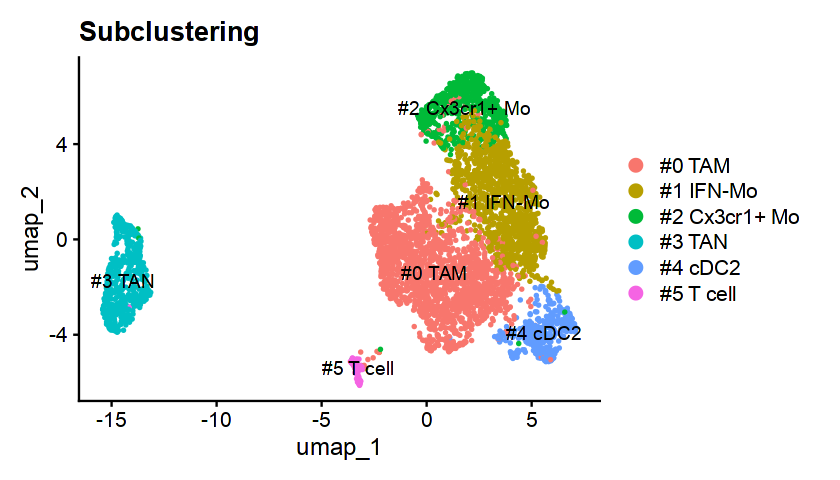

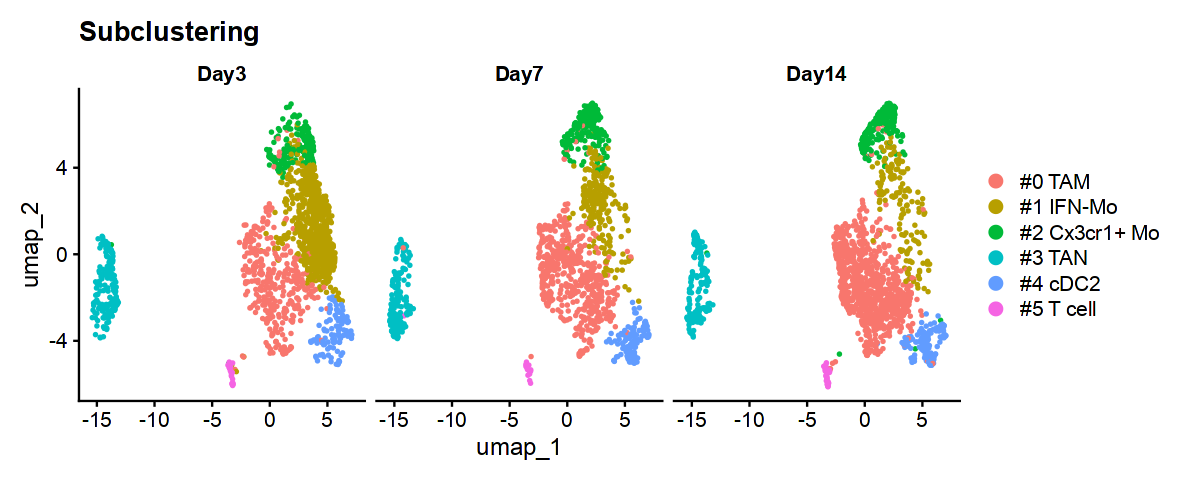

In [244]:
options(repr.plot.width = 7, repr.plot.height = 4)
p1 <- DimPlot(TIM, label = TRUE) + 
 ggtitle("Subclustering") 

p1

options(repr.plot.width = 10, repr.plot.height = 4)
p1 <- DimPlot(TIM, label = FALSE, split.by='day') + 
 ggtitle("Subclustering") 

p1

# 1. Heatmap

In [245]:
# marker
TIM_markers_annotate <- FindAllMarkers(
  TIM,
  only.pos = TRUE,
  min.pct = 0.25,
  logfc.threshold = 0.25
)

TIM_markers_annotate %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 10) %>%
    ungroup() -> top10_TIM

Calculating cluster #0 TAM

Calculating cluster #1 IFN-Mo

Calculating cluster #2 Cx3cr1+ Mo

Calculating cluster #3 TAN

Calculating cluster #4 cDC2

Calculating cluster #5 T cell



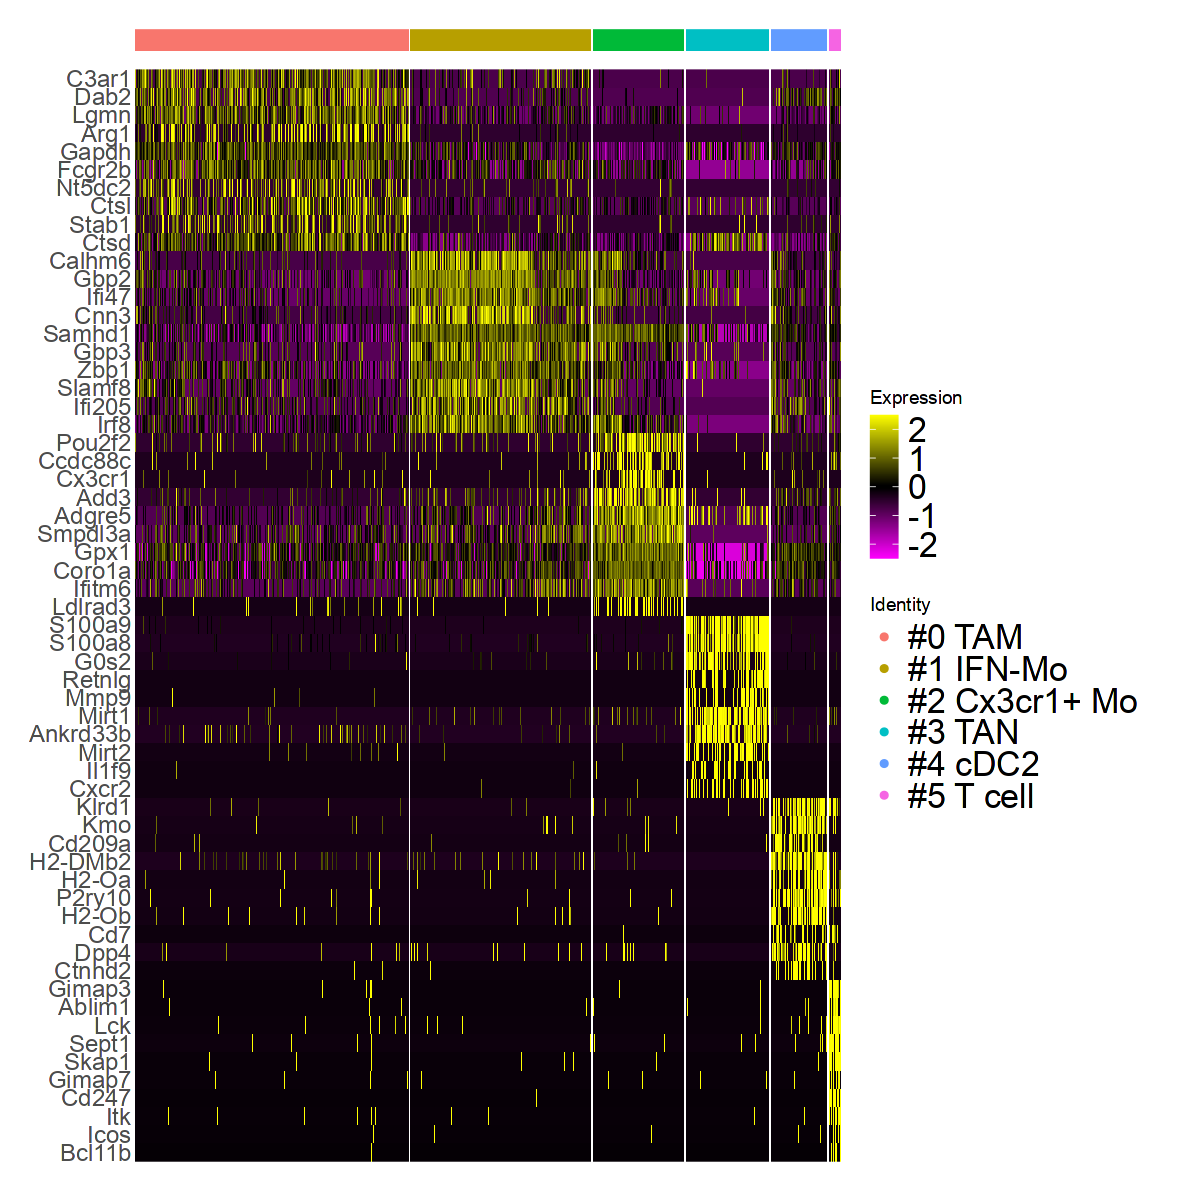

In [246]:
options(repr.plot.width = 10, repr.plot.height = 10)
p1 <- DoHeatmap(TIM, features = top10_TIM$gene, label=FALSE, size=14)+
theme(axis.text.y = element_text(size = 14),
     legend.text = element_text(size = 20))
p1

ggsave(file.path(dir_fig,"01_heatmap.jpeg"), plot = p1, width = 10, height = 10, dpi = 1200)
ggsave(file.path(dir_fig,"01_heatmap.pdf"), plot = p1, width = 10, height = 10, dpi = 1200)

# 2. UMAP/tSNE

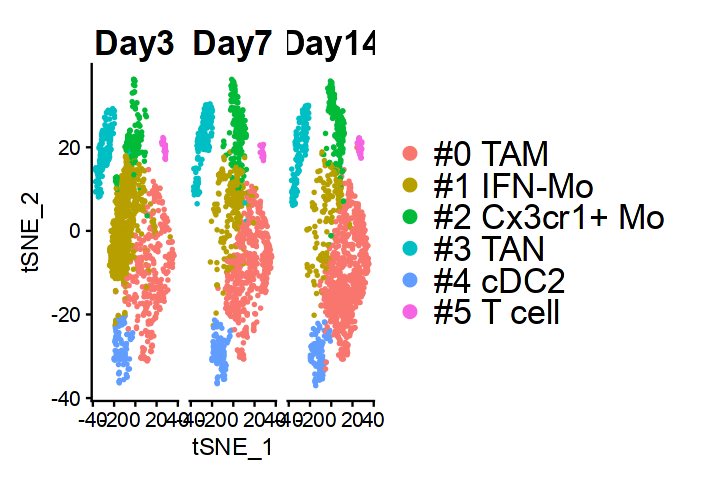

In [247]:
options(repr.plot.width = 6, repr.plot.height = 4)
p1_large <- DimPlot(TIM, reduction = "tsne", label = FALSE, split.by='day') + 
theme(legend.text = element_text(size = 20),strip.text = element_text(size = 20)) 
p1_large
ggsave(file.path(dir_fig,"01_tsne_large.jpeg"), plot = p1_large, width = 6, height = 4, dpi = 300)
ggsave(file.path(dir_fig,"01_tsne_large.pdf"), plot = p1_large, width = 6, height = 4, dpi = 300)

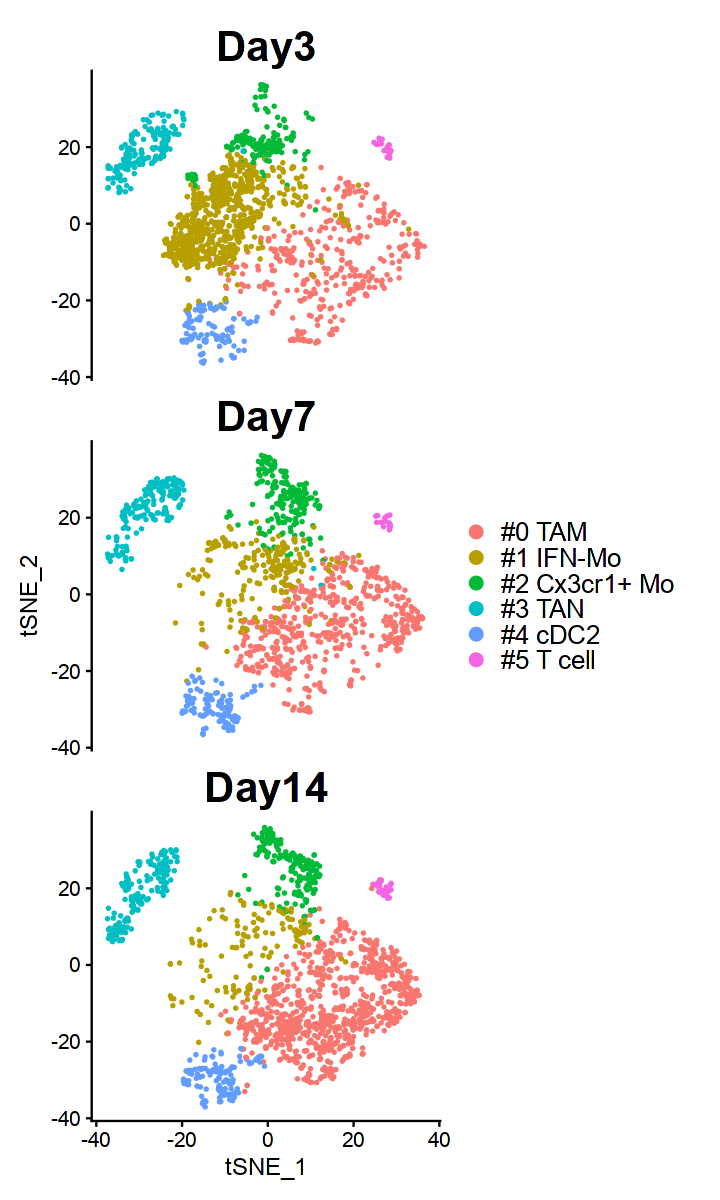

In [264]:
options(repr.plot.width = 6, repr.plot.height = 10)
p1 <- DimPlot(TIM, reduction = "tsne", label = FALSE, 
              split.by='day', ncol=1) + 
theme(strip.text = element_text(size = 25), legend.text = element_text(size = 15)) 
p1
ggsave(file.path(dir_fig,"01_tsne_v.jpeg"), plot = p1, width = 6, height = 10, dpi = 1200)
ggsave(file.path(dir_fig,"01_tsne_v.pdf"), plot = p1, width = 6, height = 10, dpi = 1200)

# 3. Annotation

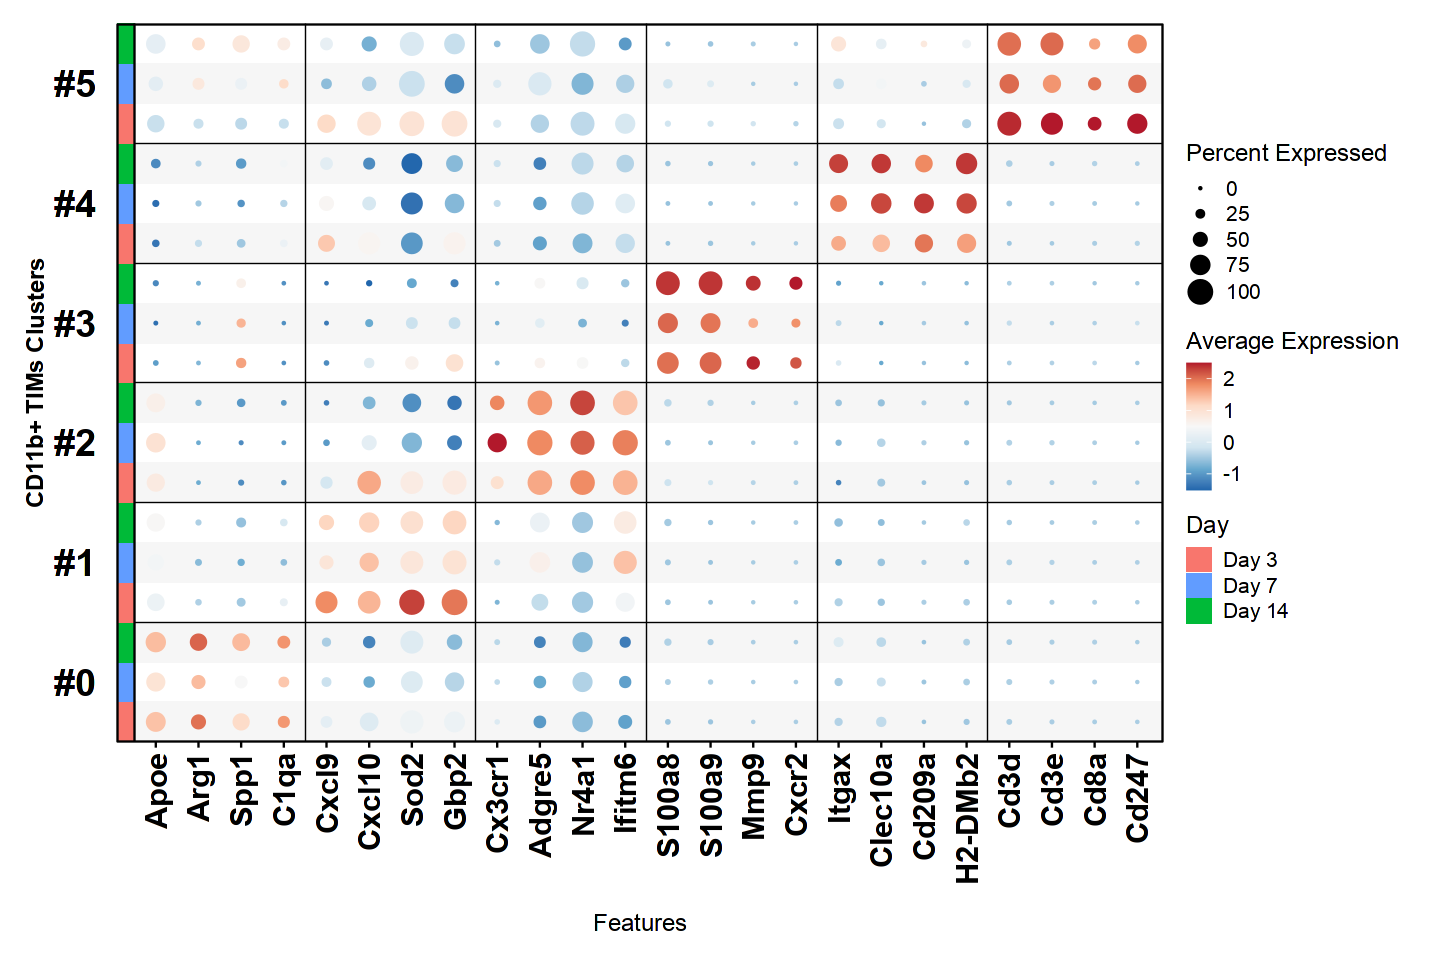

In [265]:
# ============================================================
# Parameters & inputs
# ============================================================
cluster_specific_genes1 <- c(
    "Apoe", "Arg1", "Spp1", "C1qa",          # TAM
    "Cxcl9", "Cxcl10", "Sod2", "Gbp2",       # IFNγ-Mono
    "Cx3cr1", "Adgre5", "Nr4a1", "Ifitm6",   # Cx3cr1+ Mono
    "S100a8", "S100a9", "Mmp9", "Cxcr2",     # Neutrophil
    "Itgax", "Clec10a", "Cd209a", "H2-DMb2", # cDC2
    "Cd3d", "Cd3e", "Cd8a", "Cd247"          # T cell
)

cluster_genes <- cluster_specific_genes1
n_clusters  <- 6         
n_days      <- 3                 # Day3, Day7, Day14
total_rows  <- n_clusters * n_days

# Horizontal separators between clusters (every 3 rows)
h_lines <- seq(n_days + 0.5, total_rows, by = n_days)
# Vertical separators every 4 genes
v_lines <- seq(4 + 0.5, length(cluster_genes) - 0.5, by = 4)
# Empty y-axis labels (we’ll replace visually with tiles)
new_labels <- rep(c("", "", ""), times = n_clusters)
# Midpoints of each cluster block for big cluster labels (0–4)
cluster_midpoints <- seq(from = n_days/2 + 0.5, by = n_days, length.out = n_clusters)
# Alternating stripe background (odd rows)
stripe <- data.frame(
  ymin = seq(0.5, total_rows-1,     by = 2),
  ymax = seq(1.5, total_rows, by = 2)
)
# Day color tiles to the left (inside panel)
tile_df <- data.frame(
  y   = seq_len(total_rows),
  x   = 0.3,                                  # center x of the tile column
  day = factor(rep(c("3","7","14"), times = n_clusters), levels = c("3","7","14"))
)
# Color palette for Day legend
day_colors <- c("3"="#F8766D", "7"="#619CFF", "14"="#00BA38")

# 
outsideline = 0.5

# ============================================================
# Base DotPlot (Seurat -> ggplot)
# ============================================================
p <- DotPlot(TIM, features = cluster_genes, cols = "RdBu", split.by = "day")
# Put stripe background UNDER the dots by inserting the layer
stripe_layer <- geom_rect(
  data = stripe, inherit.aes = FALSE,
  aes(xmin = -Inf, xmax = Inf, ymin = ymin, ymax = ymax),
  fill = "grey90", alpha = 0.35
)
p$layers <- c(list(stripe_layer), p$layers) # insert as bottom-most layer

# ============================================================
# Styling, separators, and axis handling
# ============================================================
p2 <- p + labs(y = "CD11b+ TIMs Clusters")+
  theme(
    axis.text.x   = element_text(angle = 90, vjust = 0.5, hjust = 1, size=18, face  = "bold"),
    axis.line.x   = element_blank(),
    axis.line.y   = element_blank(),
    axis.title.y  = element_text(
      angle = 90,          
      vjust = 0.5,         
      hjust = 0.5,         
      size  = 14,          
      face  = "bold",      
      margin = margin(r = 40)
    ),
    axis.ticks.y  = element_blank(),
    panel.border  = element_rect(color = "black", fill = NA, size = outsideline),
    plot.margin   = unit(c(1,1,1,1), "lines") # extra left margin for big labels if needed
  ) +
  # Cluster and 4-gene separators
  geom_hline(yintercept = h_lines, color = "black", linewidth = 0.3) +
  geom_vline(xintercept = v_lines, color = "black", linewidth = 0.3) +
  # Allow drawing outside panel (for -Inf text if you later move it out)
  coord_cartesian(clip = "off")

# ============================================================
# Left-side cluster labels (big numbers)
# ============================================================
p2 <- p2 +
  annotate(
    "text",
    x        = -Inf,                 # left bound of the panel
    y        = cluster_midpoints,
    label    = c("#0","#1","#2","#3", "#4", "#5"),
    hjust    = 1.5,                    # push a bit further left of the bound
    vjust    = 0.5,
    size     = 8,
    fontface = "bold"
  )

# ============================================================
# Day tiles (act like colored y-axis labels) + pseudo y-axis line
# ============================================================
p2 <- p2 +
  geom_tile(
    data = tile_df, inherit.aes = FALSE,
    aes(x = x, y = y, fill = day),
    width = 0.4, height = 1
  ) +
  # Pseudo y-axis line just to the right edge of the tiles
  geom_vline(xintercept = 0.5, color = "black", linewidth = outsideline) +
  # Day legend (fixed order 3 -> 7 -> 14)
  scale_fill_manual(
    name   = "Day",
    values = day_colors,
    breaks = c("3","7","14"),
    labels = c("Day 3","Day 7","Day 14")
  )+
# Remove y-axis text (replaced by tiles)
scale_y_discrete(labels = new_labels, expand = c(0, 0))


options(repr.plot.width = 12, repr.plot.height = 8)
p2
ggsave(file.path(dir_fig, "03_dotplot.jpeg"), plot = p2, width = 9, height = 6, dpi = 300)
ggsave(file.path(dir_fig, "03_dotplot.pdf"), plot = p2, width = 9, height = 6, dpi = 300)

# Cell number

In [250]:
get_group_proportions <- function (seuratobj, group.by = "active.ident") {
  if (group.by == "active.ident") {
    seuratobj[["active.ident"]] <- seuratobj@active.ident
  }
  # gets the total number of cells within each group
  total_populations <- seuratobj@meta.data %>% group_by(orig.ident) %>% summarize (total.pop = n())
  # gets the proportion of cells for each cell type within a group by dividing by the total
  count_populations <- seuratobj@meta.data %>% group_by_at(vars(group.by, "orig.ident")) %>% summarize (n = n())
  count_populations <- left_join(count_populations, total_populations, by = "orig.ident")
  count_populations <- count_populations %>% mutate (proportion = n/total.pop)
  count_populations
}

get_group_proportions(TIM)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by active.ident and orig.ident.
ℹ Output is grouped by active.ident.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(active.ident, orig.ident))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


active.ident,orig.ident,n,total.pop,proportion
<fct>,<chr>,<int>,<int>,<dbl>
#0 TAM,day03,345,1669,0.20671061
#0 TAM,day07,543,1281,0.42388759
#0 TAM,day14,913,1632,0.55943627
#1 IFN-Mo,day03,805,1669,0.48232475
#1 IFN-Mo,day07,236,1281,0.18423107
#1 IFN-Mo,day14,147,1632,0.09007353
#2 Cx3cr1+ Mo,day03,198,1669,0.11863391
#2 Cx3cr1+ Mo,day07,194,1281,0.15144418
#2 Cx3cr1+ Mo,day14,210,1632,0.12867647


In [251]:
plot_group_proportions <- function (seuratobj, graph.type = "dodge") {
  # get the proportions using get_group_proportions()
  count_populations <- get_group_proportions(seuratobj)
  # plot the proportions
  if (graph.type == "dodge"){
  ggplot(count_populations, aes (x = active.ident, y = proportion))+
    geom_bar (aes(fill = orig.ident), stat = "identity", position = "dodge")+
      theme(axis.text.x = element_text(angle=45, hjust = 1))
  } else if (graph.type == "stacked") {
  ggplot(count_populations, aes (x = orig.ident, y = proportion))+
    geom_bar (aes(fill = active.ident), stat = "identity", position = "fill")
  }
  else
    print("invalid graph type")
}

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by active.ident and orig.ident.
ℹ Output is grouped by active.ident.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(active.ident, orig.ident))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


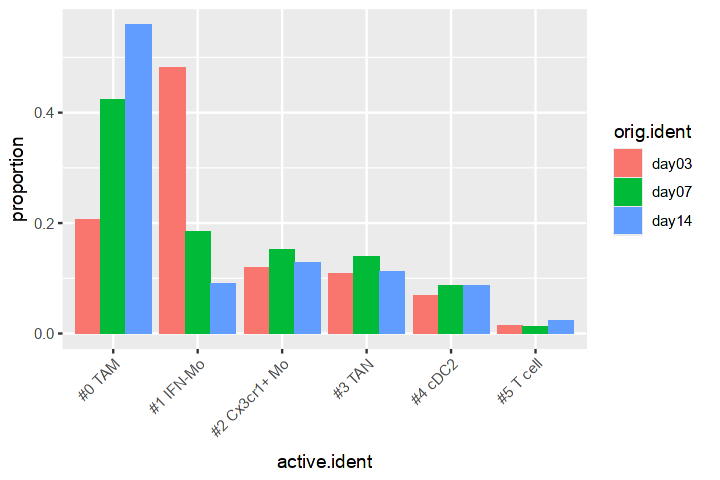

In [252]:
options(repr.plot.width = 6, repr.plot.height = 4)
p7 <- plot_group_proportions(TIM, graph.type = "dodge")
p7

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by active.ident and orig.ident.
ℹ Output is grouped by active.ident.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(active.ident, orig.ident))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


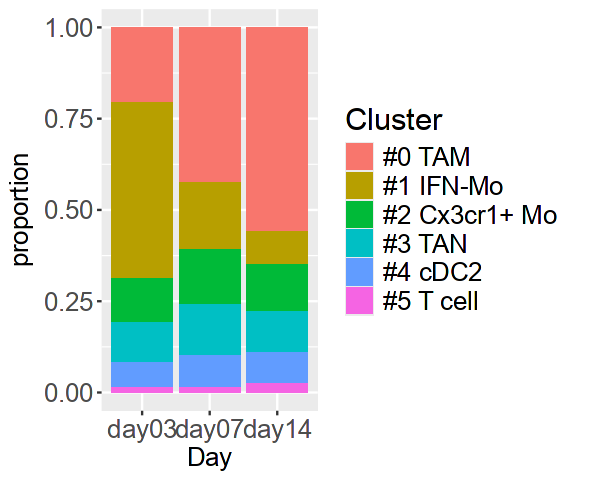

In [267]:
options(repr.plot.width = 5, repr.plot.height = 4)
p3_n <- plot_group_proportions(TIM, graph.type = "stacked")+
　labs(x = "Day", fill="Cluster") + 
  theme(
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 18),  
    strip.text = element_text(size = 25),
    axis.title.x = element_text(size = 15),  
    axis.title.y = element_text(size = 15),  
    axis.text.x = element_text(size = 15),   
    axis.text.y = element_text(size = 15)   
  )
p3_n

ggsave(file.path(dir_fig, "04_proportion_n.jpeg"), plot = p3_n, width = 5, height = 4, dpi = 1200)
ggsave(file.path(dir_fig, "04_proportion_n.pdf"), plot = p3_n, width = 5, height = 4, dpi = 1200)

In [268]:
saveRDS(TIM, file = file.path(dir_int, "TIM.rds"))